In [73]:
""" Compare against pore water chemistry data of Natalie/Verity
Measurements depths are relative to hollow surface"""
import pandas as pd
import numpy as np
import os
from datetime import datetime
from utils.analysis import vert_interp
from utils.constants import chamber_levels_complete, chamber_list_complete_dict
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap
from glob import glob
import xarray as xr
from scipy.stats import pearsonr, spearmanr, chi2, probplot
from statsmodels.tools import add_constant
from statsmodels.regression.mixed_linear_model import MixedLM

chambers_ordered = {
    'amb': ['07', '06', '20', '13', '08', '17'], 
    'elev': ['19', '11', '04', '16', '10']
}
xticklabels = ['TAMB', 'T0.00', 'T2.25','T4.50', 'T6.75', 'T9.00', 
               'T0.00CO2', 'T2.25CO2', 'T4.5CO2', 'T6.75CO2', 'T9.00CO2']

# which depth of observation to look at, pick from depth_list
depth_list = ['0.0', '0.3', '0.5', '1.0', '2.0', '3.0']
DEPTH = 0.3

In [54]:
# Observed dissolved N & P at multiple depths
data = pd.read_csv(
    os.path.join(os.environ['PROJDIR'], 'ELM_Phenology', 'input', 
                 'SPRUCE_plot_porewater_chemistry_release_20240617.csv'),
    na_values=[-9999, -8888]
)
data['DATE'] = data['DATE'].apply(lambda x: datetime.strptime(str(x), '%Y%m%d'))
data = data.loc[(pd.DatetimeIndex(data['DATE']).year >= 2015) & 
                (~data['PLOT'].isin([2,5,9,14,15,21])), 
                ['PLOT', 'DEPTH', 'DATE', 'NH4', 'NO3', 'SRP', 'TN', 'TP']]
data['PLOT'] = [f'{x:02d}' for x in data['PLOT']]
data['dT'] = [chamber_levels_complete[x][0] for x in data['PLOT']]
data['CO2'] = [chamber_levels_complete[x][1] for x in data['PLOT']]

data['NH4+NO3'] = data['NH4'] + data['NO3']

data = data.loc[np.isclose(data['DEPTH'], DEPTH), :]
data = data.sort_values(by = 'DATE')

if DEPTH == 0.3:
    # apparently there is some outlier
    data.loc[data['PLOT'].isin(['10', '19']) & (data['NH4'] > 1.5)] = np.nan

OSError: [Errno 116] Stale file handle: '/gpfs/wolf2/cades/cli185/scratch/ywo/ELM_Phenology/input/SPRUCE_plot_porewater_chemistry_release_20240617.csv'

In [3]:
# Collect modeled dissolved nutrients, layersize
ensemble_id = None
year_range = range(2015, 2022)
plot_list = list(chamber_levels_complete.keys())
prefix_list = ['20231113', '20240321']

tvec = pd.date_range('2015-01-01', '2021-12-31')
tvec = tvec[(tvec.month != 2) | (tvec.day != 29)]
sims_data = {}

for prefix in prefix_list:
    sims_data[(prefix, 'SMIN_NO3_vr')] = \
        pd.DataFrame(np.nan, 
                    columns = pd.MultiIndex.from_product([['hummock', 'hollow', 'average'],
                                                            plot_list]),
                    index = tvec)
    sims_data[(prefix, 'SMIN_NH4_vr')] = sims_data[(prefix, 'SMIN_NO3_vr')].copy()
    sims_data[(prefix, 'SMINN_vr')] = sims_data[(prefix, 'SMIN_NO3_vr')].copy()
    sims_data[(prefix, 'SOLUTIONP_vr')] = sims_data[(prefix, 'SMIN_NO3_vr')].copy()

    for plot in plot_list:
        if not "UQ" in prefix:
            rundir = os.path.join(os.environ['E3SM_ROOT'], 'output', 
                                f'{prefix}_US-SPR_ICB20TRCNPRDCTCBC', f'spruce_treatments', 
                                f'plot{plot}_US-SPR_ICB20TRCNPRDCTCBC', 'run')
        else:
            rundir = os.path.join(os.environ['E3SM_ROOT'], 'output', 'UQ',
                                f'{prefix}_US-SPR_ICB20TRCNPRDCTCBC', ensemble_id, 
                                f'P{chamber_list_complete_dict[plot]}')

        flist = sorted(glob(rundir + "/*.h1.*.nc"))
        flist = [f for f in flist if \
                int(f.split('/')[-1].split('.')[-2].split('-')[0]) in year_range]
        hr = xr.open_mfdataset(flist)

        for var in ['SMINN_vr', 'SMIN_NH4_vr', 'SMIN_NO3_vr', 'SOLUTIONP_vr']:
            LEVGRND = np.array([0.007100635, 0.027925, 0.06225858, 0.1188651, 0.2121934,
                                0.3660658, 0.6197585, 1.038027, 1.727635, 2.864607, 4.739157,
                                7.829766, 12.92532, 21.32647, 35.17762])
            LEVGRND_I = np.append(np.insert(
                (LEVGRND[1:] + LEVGRND[:-1])*0.5, 0, 0
            ), LEVGRND[-1] + 0.5 * (LEVGRND[-1] - LEVGRND[-2]))
            THICKNESS = np.diff(LEVGRND_I)

            target_nodes = [DEPTH]
            input_nodes = LEVGRND
            target_single_level = True

            for col, colname in enumerate(['hummock', 'hollow']):
                input_data = hr[var][:, :, col].values / hr['H2OSOI'][:, :, col].values

                result = vert_interp(target_nodes, input_nodes, input_data, 
                                    target_single_level)
                sims_data[(prefix, var)].loc[:, (colname, plot)] = result[:, 0]
        hr.close()

    for var in ['SMINN_vr', 'SMIN_NH4_vr', 'SMIN_NO3_vr', 'SOLUTIONP_vr']:
        sims_data[(prefix, var)].loc[:, 'average'] = \
            sims_data[(prefix, var)].loc[:, 'hummock'].values * 0.64 + \
            sims_data[(prefix, var)].loc[:, 'hollow'].values * 0.36

In [79]:
##############################################################
# Linear mixed effects model
# y ~ year + nominal trmt temperature + year x trmt + CO2
##############################################################
for sim_name, obs_name in zip(
    ['SMIN_NH4_vr', 'SMIN_NO3_vr', 'SOLUTIONP_vr'], ['NH4', 'NO3', 'SRP']
):
    design_matrix = {}
    
    # observed data
    #obs_data_var = data[['PLOT', 'DATE', obs_name]
    #                            ].set_index(['DATE', 'PLOT']).iloc[:,0].dropna().unstack()
    design_matrix['Obs'] = obs_data_var.stack()

    for p, (prefix, name) in enumerate(zip(prefix_list, ['default','nutrient'])):

        # growing season simulated data
        sims_data_var = sims_data[(prefix, sim_name)]
        sims_data_var = sims_data_var.loc[:, 'hollow']

        sims_data_matched = pd.DataFrame(np.nan, index = obs_data_var.index, 
                                         columns = obs_data_var.columns)
        for plot in chambers_ordered['amb'] + chambers_ordered['elev']:
            sims_data_matched.loc[:, plot] = \
                sims_data_var.loc[obs_data_var.index, plot]

        design_matrix[name] = sims_data_matched.stack()
    
    design_matrix = pd.DataFrame(design_matrix)

    tvec = design_matrix.index.get_level_values(0)
    design_matrix['Time'] = (tvec - tvec[0]).days
    design_matrix['CO2'] = [int(t in chambers_ordered['elev']) for t in \
                            design_matrix.index.get_level_values(1)]
    design_matrix['Tair'] = [
        chamber_levels_complete[p][0] for p in design_matrix.index.get_level_values(1)
    ]
    design_matrix['Chamber'] = design_matrix.index.get_level_values(1)

    #######################################
    # Loop through to fit the same model
    #######################################
    result = {}
    for prefix in ['Obs', 'default', 'nutrient']:
        df = design_matrix[[prefix, 'Time', 'CO2', 'Tair', 'Chamber']].dropna(how = 'any')
        model = MixedLM.from_formula(
            f'{prefix} ~ Time + CO2 + Tair + Tair:CO2 + Time:Tair',
            groups = 'Chamber', 
            re_formula = '~Time', # random intercepts and slopes for time within chamber
            data = df)
        result[prefix] = model.fit()
        print(result[prefix].summary())

        dummy()

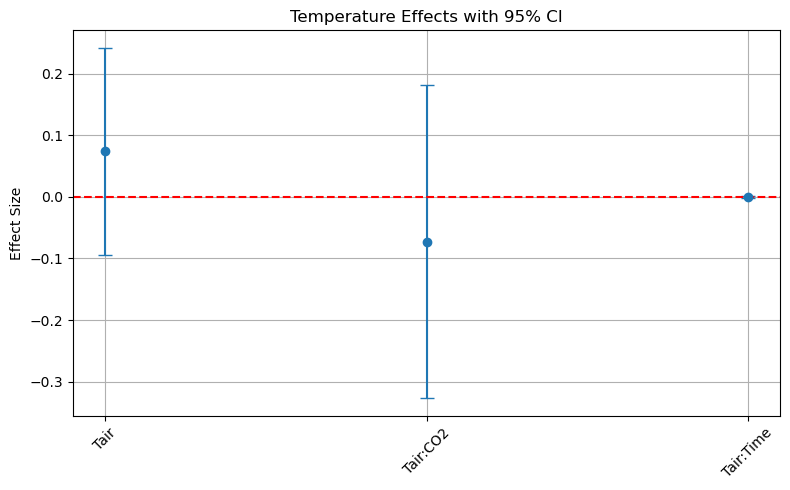

<Figure size 800x500 with 0 Axes>

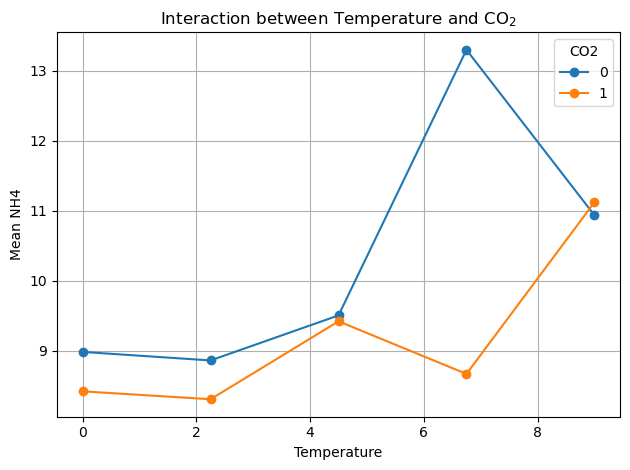

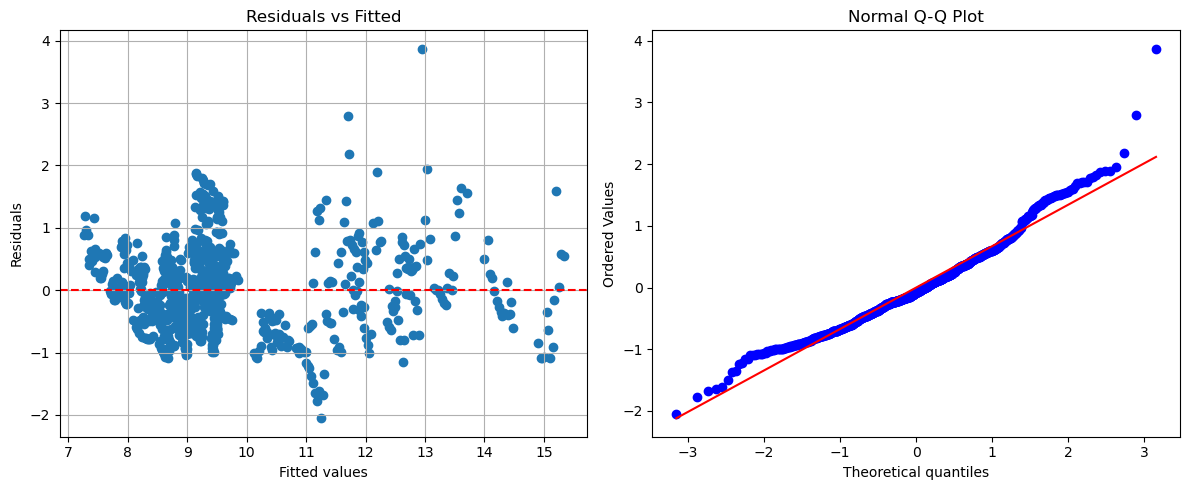


3. Tests of Interactions:
Temperature x CO$_2$ interaction: chi2 = 0.31, p = 0.5762


In [74]:
prefix = 'Obs'

# 2. Effect size plot for temperature levels
tair_effects = result.params[result.params.index.str.startswith('Tair')]
tair_std_errors = result.bse[result.params.index.str.startswith('Tair')]

plt.figure(figsize=(8, 5))
plt.errorbar(range(len(tair_effects)), tair_effects, yerr=1.96*tair_std_errors,
             fmt='o', capsize=5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xticks(range(len(tair_effects)), tair_effects.index)
plt.title('Temperature Effects with 95% CI')
plt.ylabel('Effect Size')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

# 3. Interaction plot between temperature and CO2
plt.figure(figsize=(8, 5))
means = df.groupby(['Tair', 'CO2'])[prefix].mean().unstack()
means.plot(marker='o')
plt.title('Interaction between Temperature and CO$_2$')
plt.xlabel('Temperature')
plt.ylabel(f'Mean {obs_name}')
plt.grid(True)
plt.tight_layout()
plt.show()

# Model diagnostics
residuals = result.resid
fitted = result.fittedvalues

# Residual plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Residuals vs fitted
ax1.scatter(fitted, residuals)
ax1.axhline(y=0, color='r', linestyle='--')
ax1.set_xlabel('Fitted values')
ax1.set_ylabel('Residuals')
ax1.set_title('Residuals vs Fitted')
ax1.grid(True)

# QQ plot
probplot(residuals, dist="norm", plot=ax2)
ax2.set_title('Normal Q-Q Plot')

plt.tight_layout()
plt.show()

# Test significance of interactions
def test_interaction(model, term1, term2):
    """Test significance of interaction between two terms"""
    params = model.params
    interaction_params = params[params.index.str.contains(f"{term1}.*{term2}")]
    cov_matrix = model.cov_params()
    interaction_cov = cov_matrix.loc[interaction_params.index, interaction_params.index]
    
    # Wald test
    chi2_stat = interaction_params.T.dot(np.linalg.inv(interaction_cov)).dot(interaction_params)
    p_value = 1 - chi2.cdf(chi2_stat, df=len(interaction_params))

    return chi2_stat, p_value

# Test nutrition:additive interaction
chi2_stat, p_val = test_interaction(result, "Tair", "CO2")
print("\n3. Tests of Interactions:")
print(f"Temperature x CO$_2$ interaction: chi2 = {chi2_stat:.2f}, p = {p_val:.4f}")

/tmp/ipykernel_2841868/2370230696.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = get_cmap('magma_r')
/tmp/ipykernel_2841868/2370230696.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = get_cmap('magma_r')


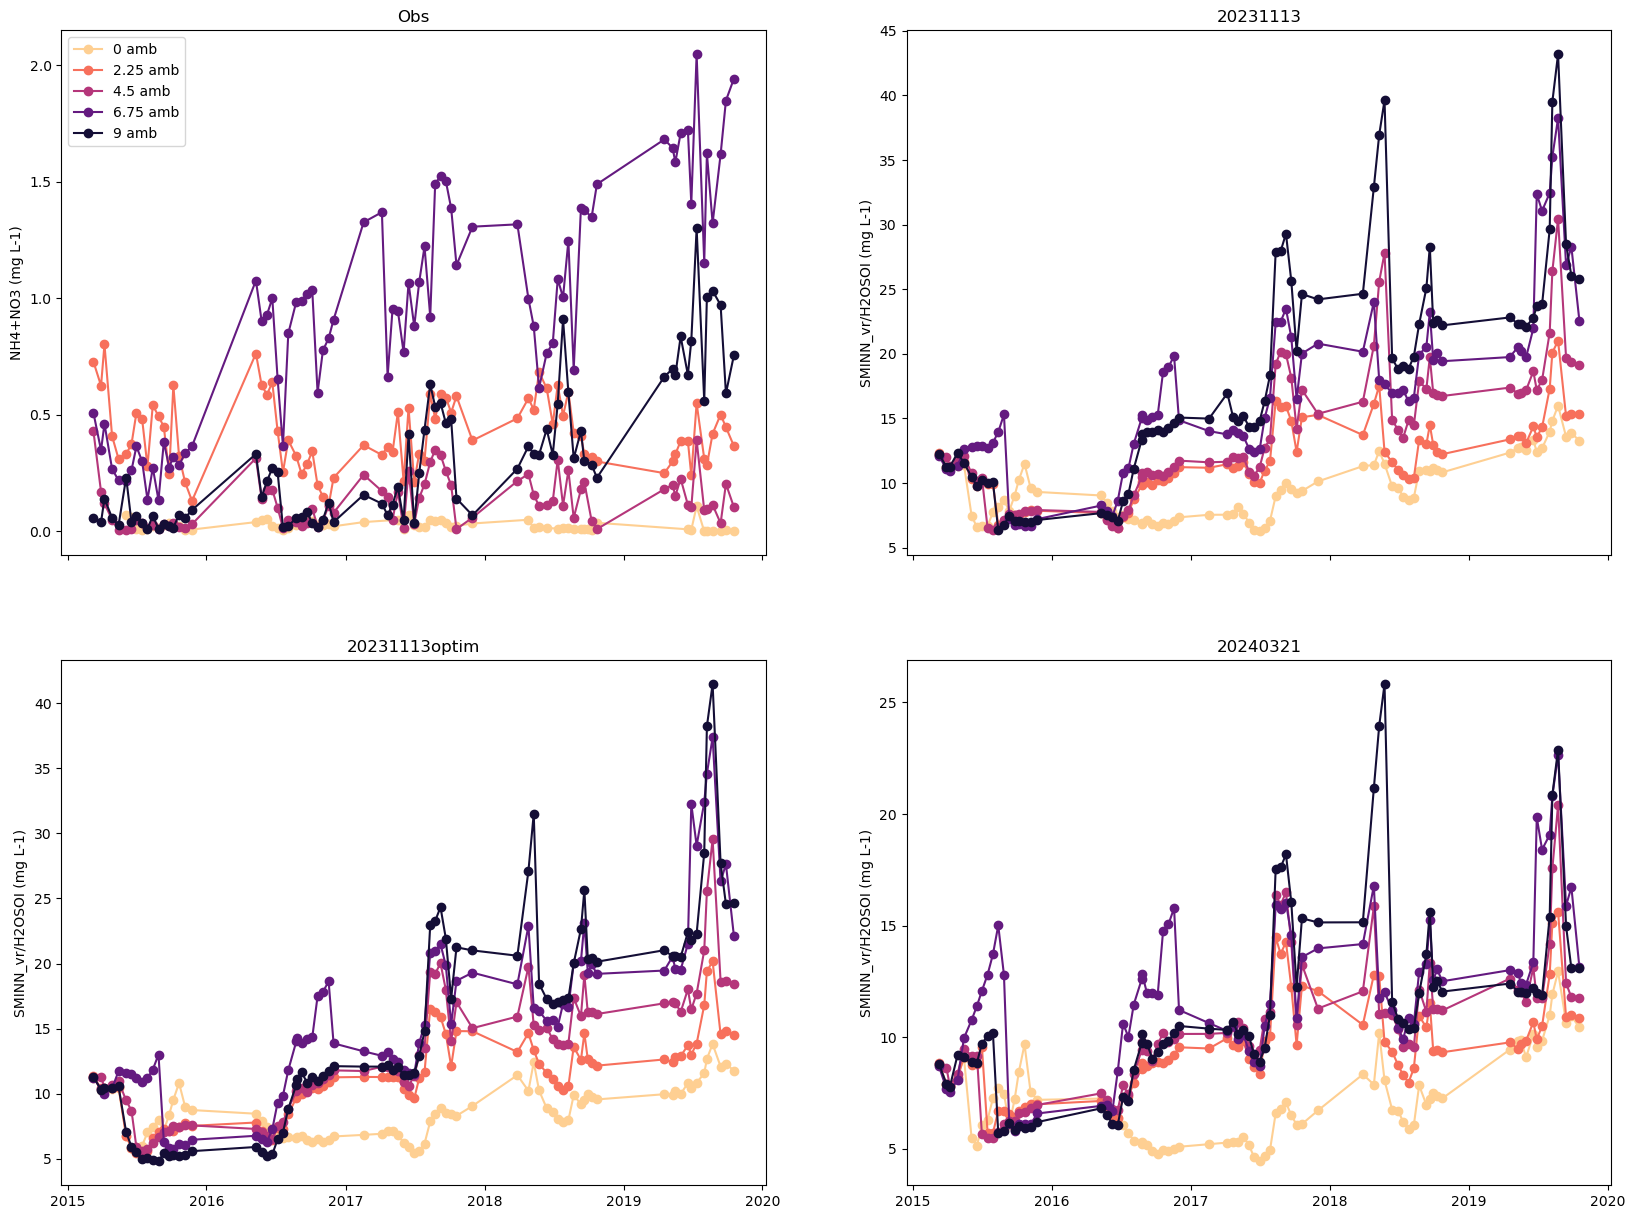

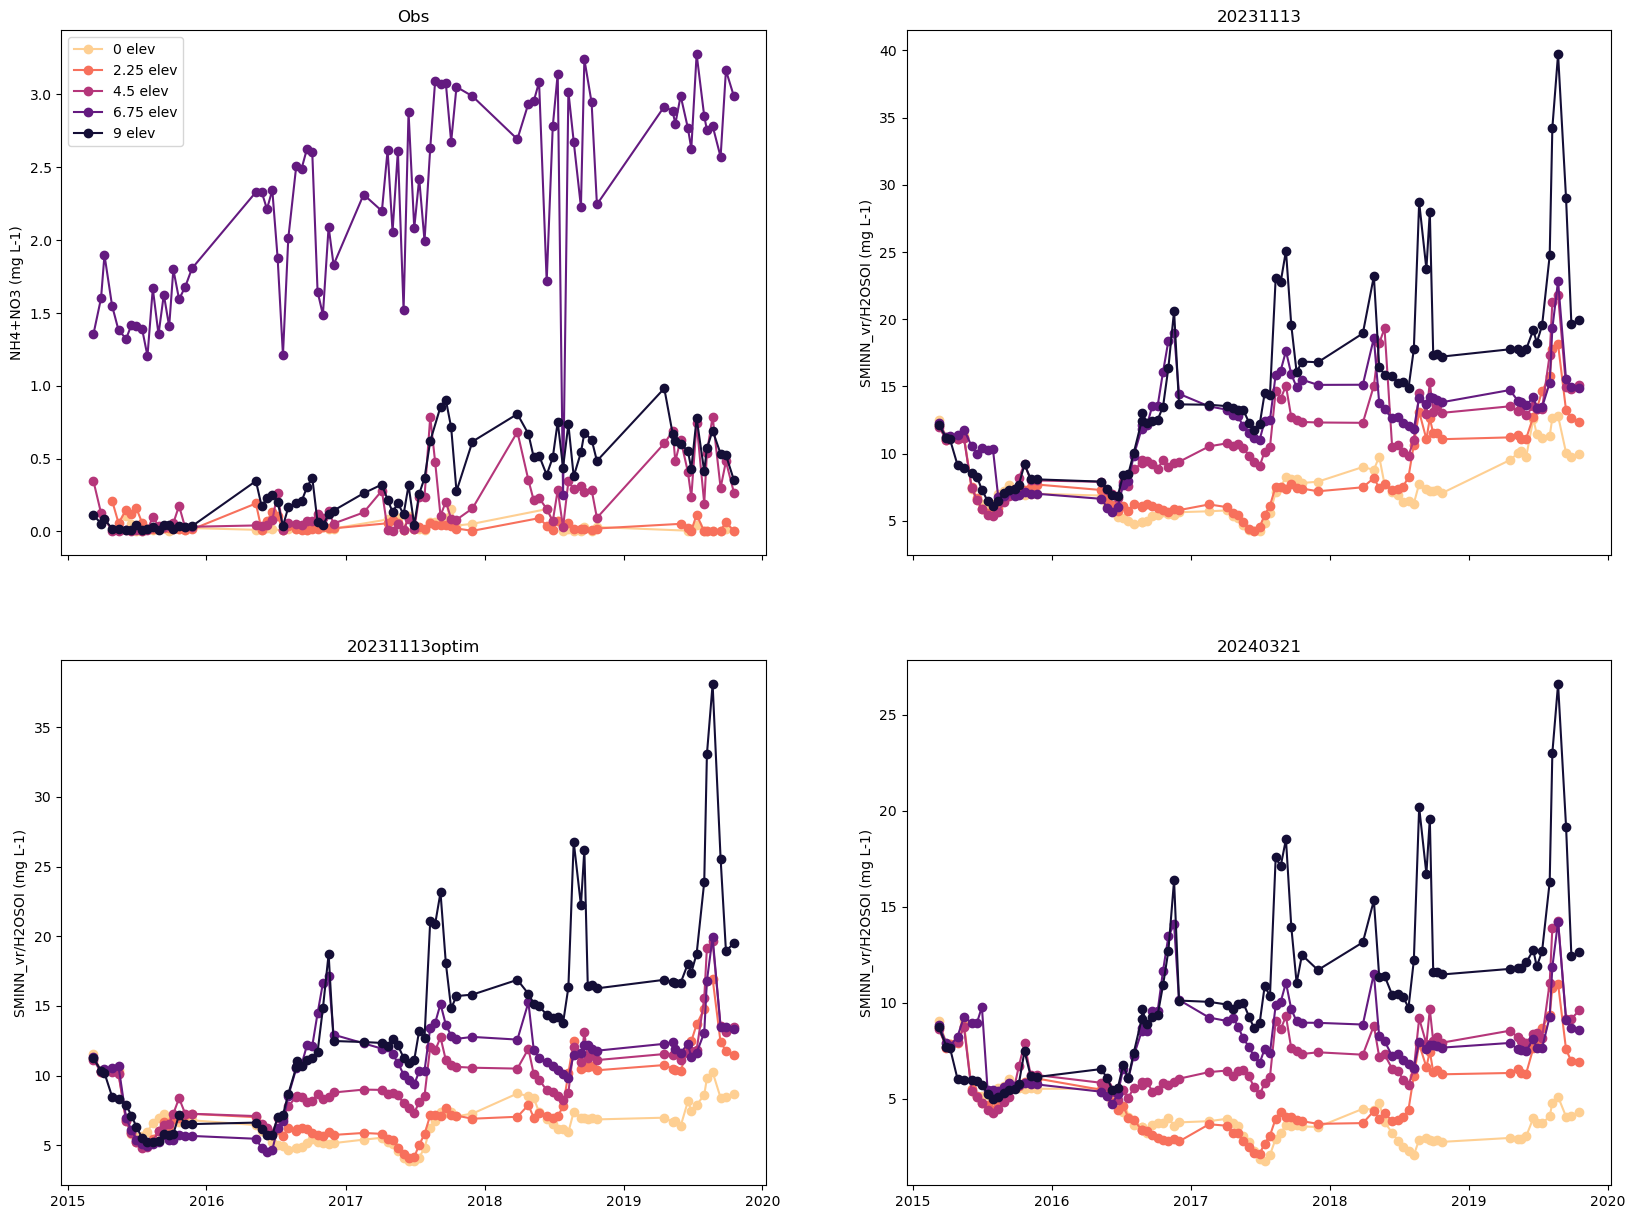

In [5]:
for co2 in ['amb', 'elev']:
    if co2 == 'amb':
        label_list = xticklabels[:5]
    else:
        label_list = xticklabels[5:]

    fig, axes = plt.subplots(2, 2, figsize = (20, 15), sharex = True, sharey = False)

    cmap = get_cmap('magma_r')
    clist = [ cmap((i+0.5) / 5) for i in range(5) ]

    # observation
    ax = axes.flat[0]
    count = 0
    for plot, label in zip(chambers_ordered[co2], label_list):
        ax.plot(data.loc[data['PLOT'] == plot, 'DATE'], 
                data.loc[data['PLOT'] == plot, 'NH4+NO3'], 
                '-o', label = label, color = clist[count])
        count += 1
    ax.legend()
    ax.set_title('Obs')
    ax.set_ylabel('NH4+NO3 (mg L-1)')

    obs_data_var = data[['PLOT', 'DATE', obs_name]
                        ].set_index(['DATE', 'PLOT']).iloc[:,0].dropna().unstack()

    # simulations
    for p, prefix in enumerate(prefix_list, 1):

        # growing season simulated data
        sims_data_var = sims_data[(prefix, 'SMINN_vr')]
        sims_data_var = sims_data_var.loc[:, 'hummock']

        sims_data_matched = pd.DataFrame(np.nan, index = obs_data_var.index, 
                                        columns = obs_data_var.columns)
        for plot in chambers_ordered['amb'] + chambers_ordered['elev']:
            sims_data_matched.loc[:, plot] = \
                sims_data_var.loc[obs_data_var.index, plot]

        ax = axes.flat[p]
        count = 0
        for plot, label in zip(chambers_ordered[co2], label_list):
            ax.plot(sims_data_matched.index, 
                    sims_data_matched.loc[:, plot], 
                    '-o', label = label, color = clist[count])
            count += 1
            ax.set_title(prefix)
            ax.set_ylabel('SMINN_vr/H2OSOI (mg L-1)')

/tmp/ipykernel_2841868/1428803154.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = get_cmap('magma_r')
/tmp/ipykernel_2841868/1428803154.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = get_cmap('magma_r')


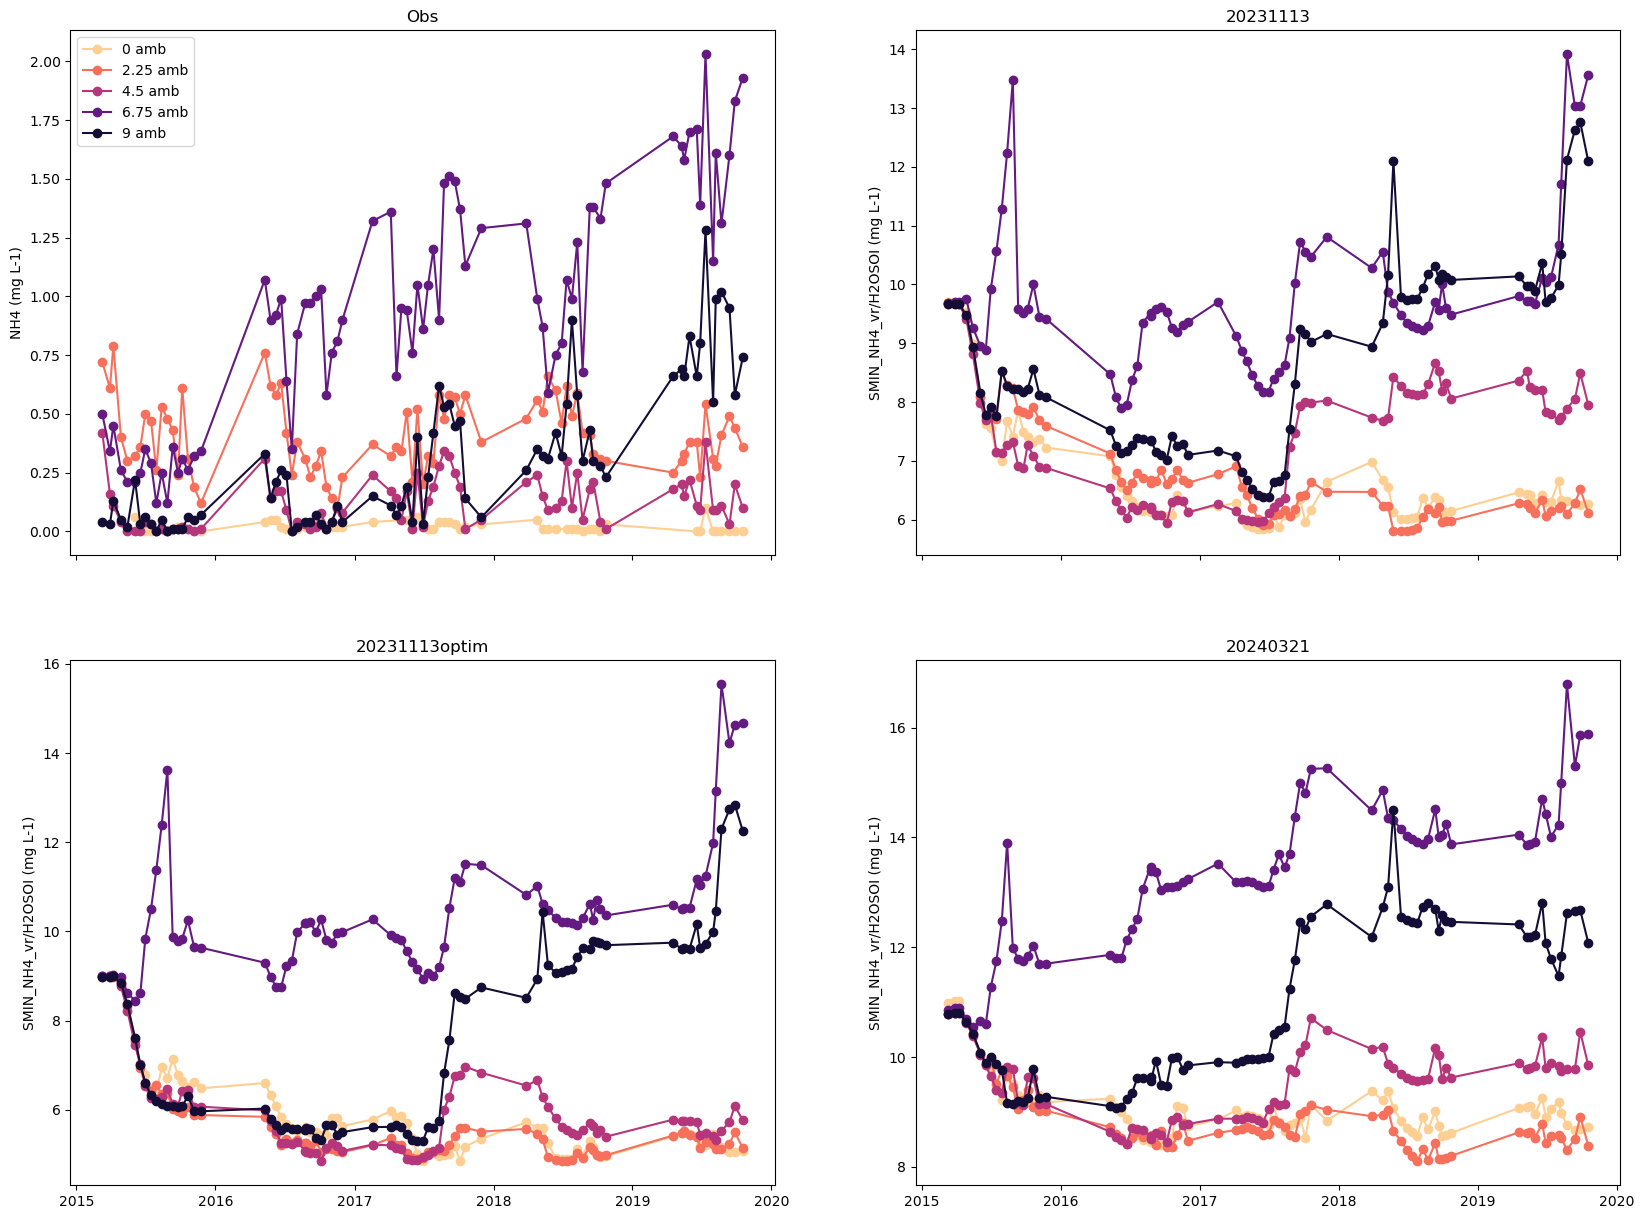

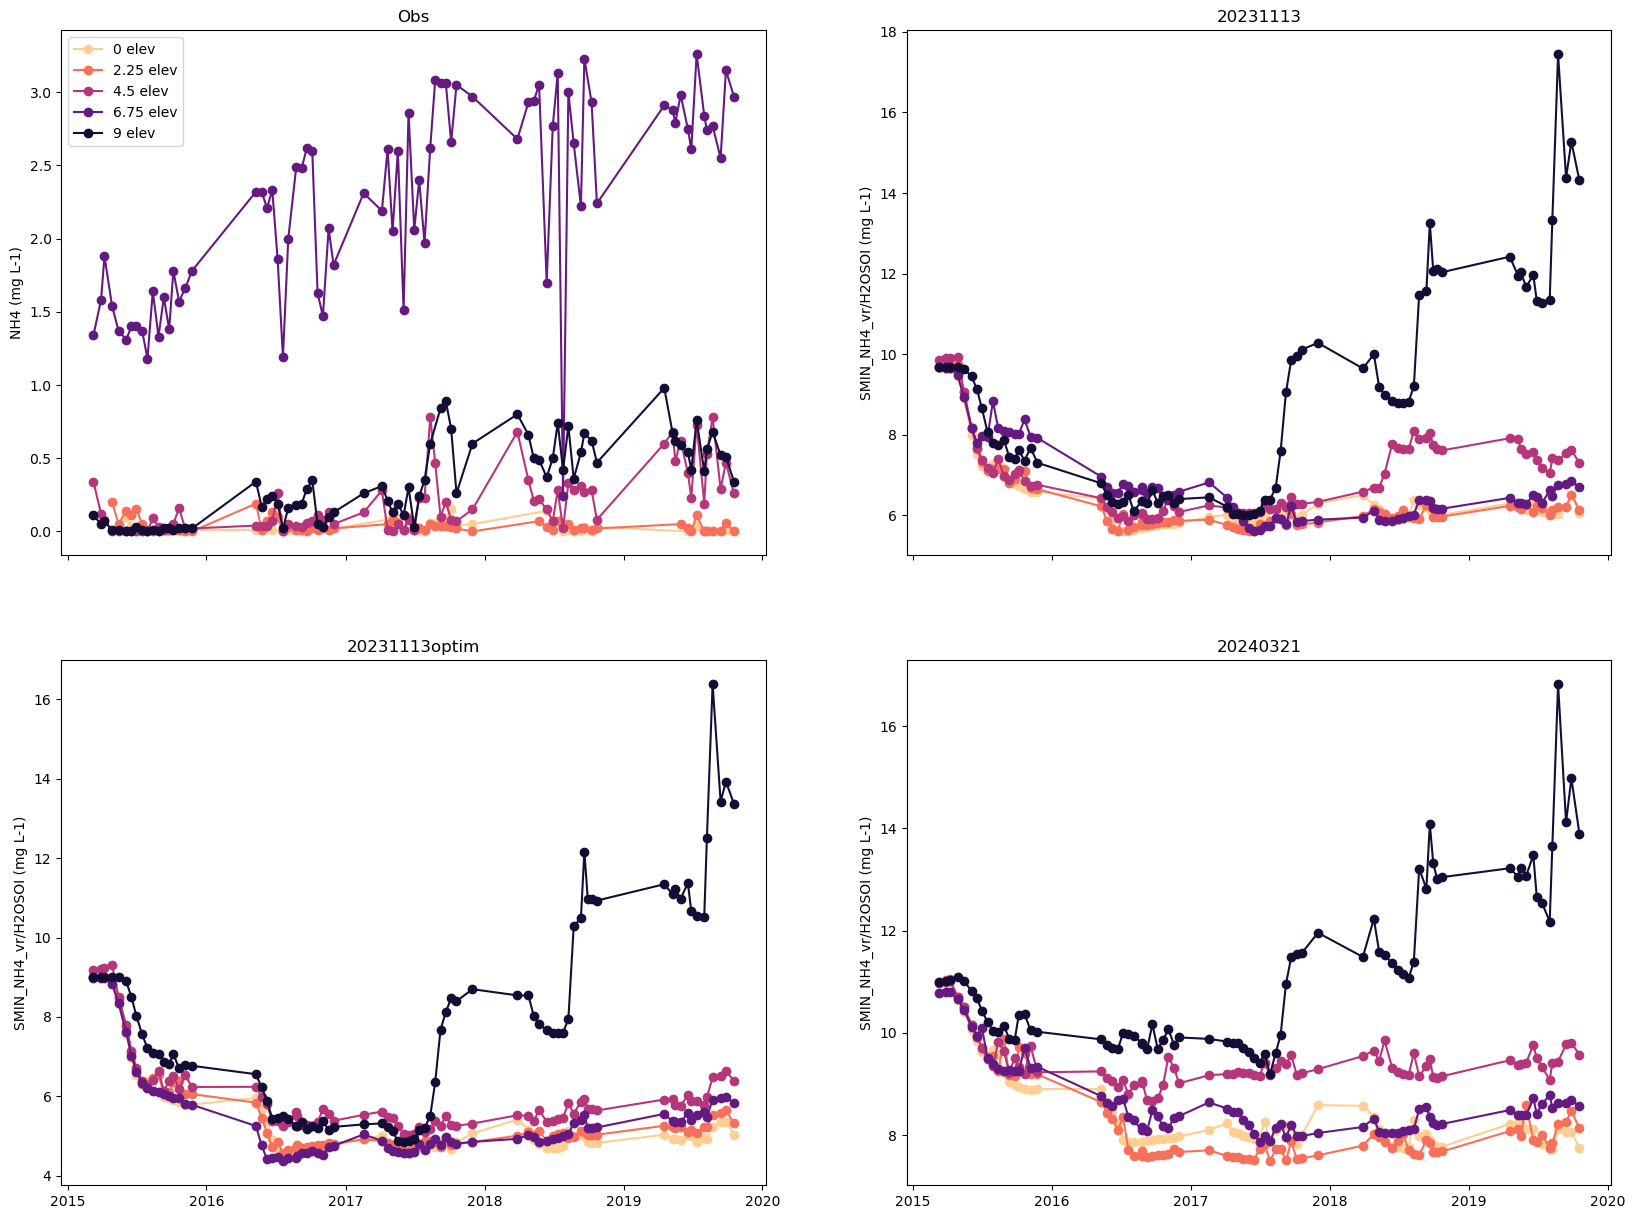

In [6]:
for co2 in ['amb', 'elev']:
    if co2 == 'amb':
        label_list = xticklabels[:5]
    else:
        label_list = xticklabels[5:]

    fig, axes = plt.subplots(2, 2, figsize = (20, 15), sharex = True, sharey = False)

    cmap = get_cmap('magma_r')
    clist = [ cmap((i+0.5) / 5) for i in range(5) ]

    # observation
    ax = axes.flat[0]
    count = 0
    for plot, label in zip(chambers_ordered[co2], label_list):
        ax.plot(data.loc[data['PLOT'] == plot, 'DATE'], 
                data.loc[data['PLOT'] == plot, 'NH4'], 
                '-o', label = label, color = clist[count])
        count += 1
    ax.legend()
    ax.set_title('Obs')
    ax.set_ylabel('NH4 (mg L-1)')

    obs_data_var = data[['PLOT', 'DATE', obs_name]
                        ].set_index(['DATE', 'PLOT']).iloc[:,0].dropna().unstack()

    # simulations
    for p, prefix in enumerate(prefix_list, 1):

        # growing season simulated data
        sims_data_var = sims_data[(prefix, 'SMIN_NH4_vr')]
        sims_data_var = sims_data_var.loc[:, 'hollow']

        sims_data_matched = pd.DataFrame(np.nan, index = obs_data_var.index, 
                                        columns = obs_data_var.columns)
        for plot in chambers_ordered['amb'] + chambers_ordered['elev']:
            sims_data_matched.loc[:, plot] = \
                sims_data_var.loc[obs_data_var.index, plot]

        ax = axes.flat[p]
        count = 0
        for plot, label in zip(chambers_ordered[co2], label_list):
            ax.plot(sims_data_matched.index, 
                    sims_data_matched.loc[:, plot], 
                    '-o', label = label, color = clist[count])
            count += 1
            ax.set_title(prefix)
            ax.set_ylabel('SMIN_NH4_vr/H2OSOI (mg L-1)')

# Convert to Table of correlations

/tmp/ipykernel_2841868/2072505649.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = get_cmap('magma_r')
/tmp/ipykernel_2841868/2072505649.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = get_cmap('magma_r')


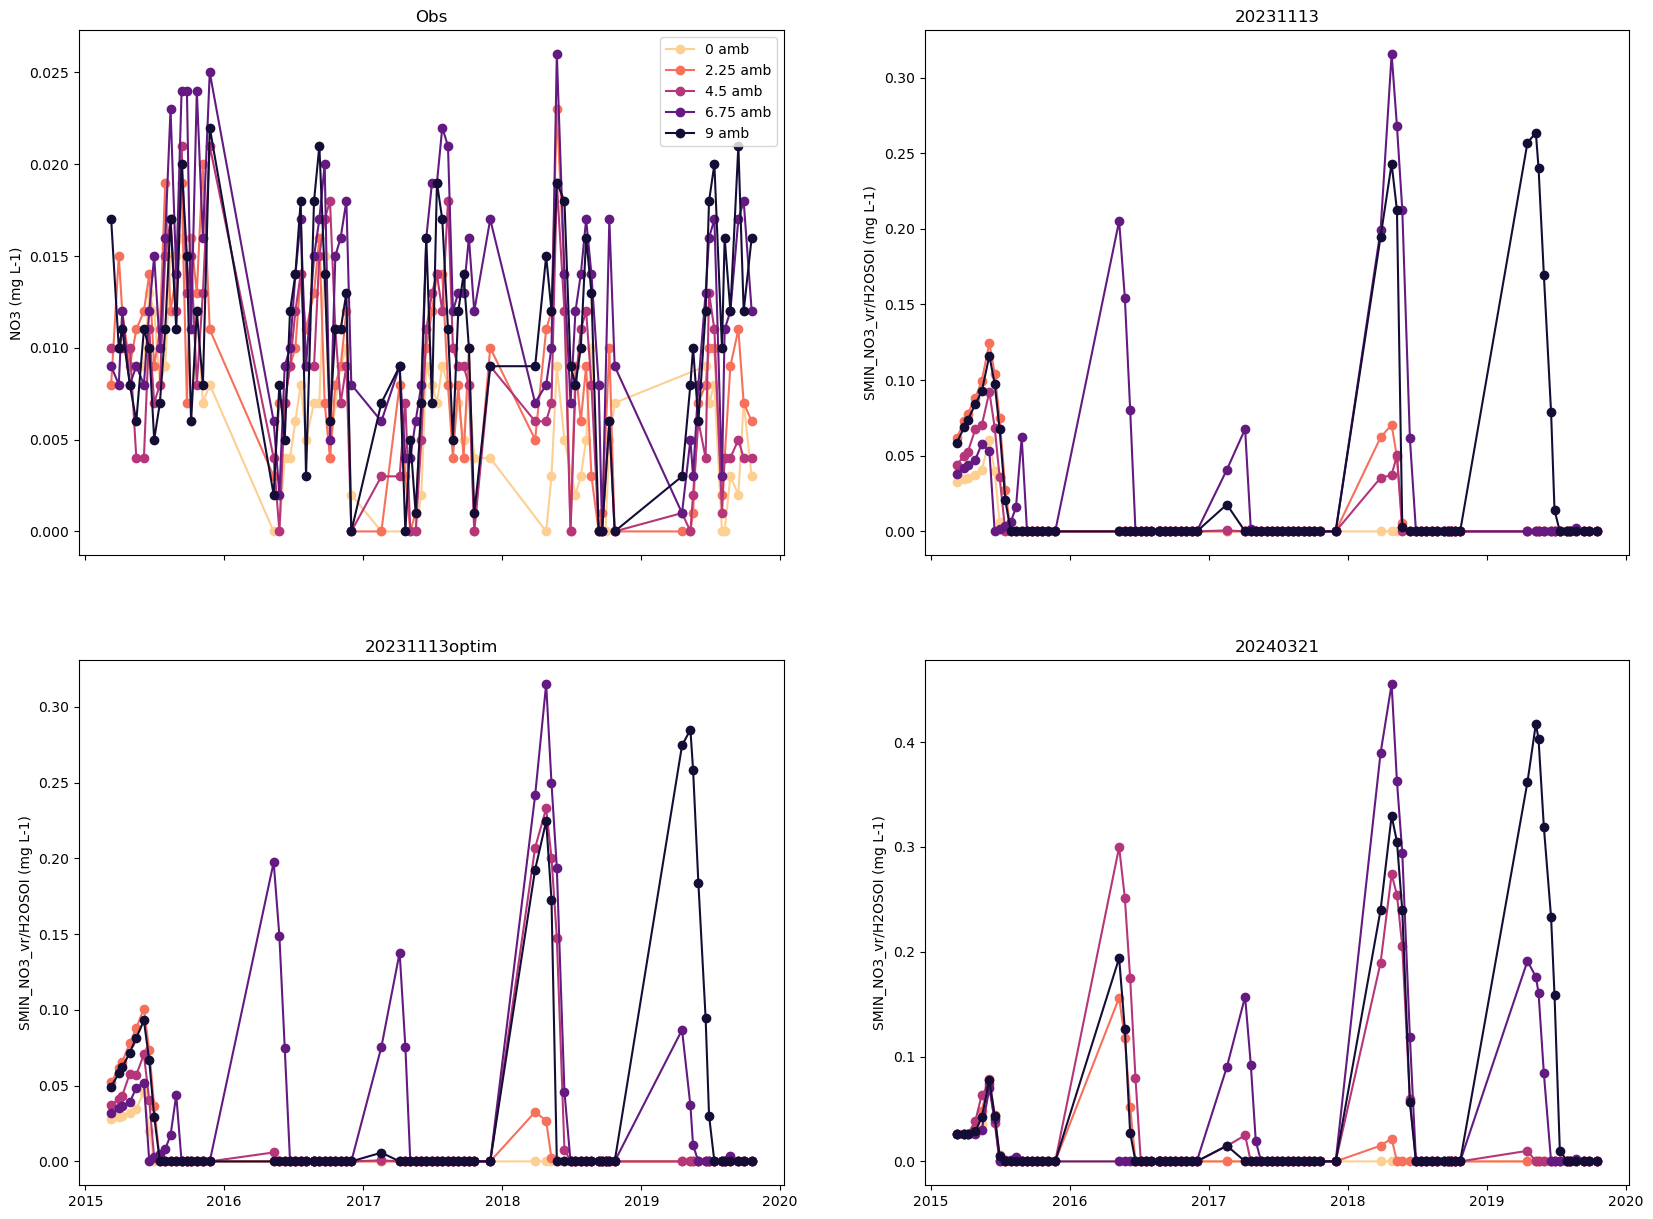

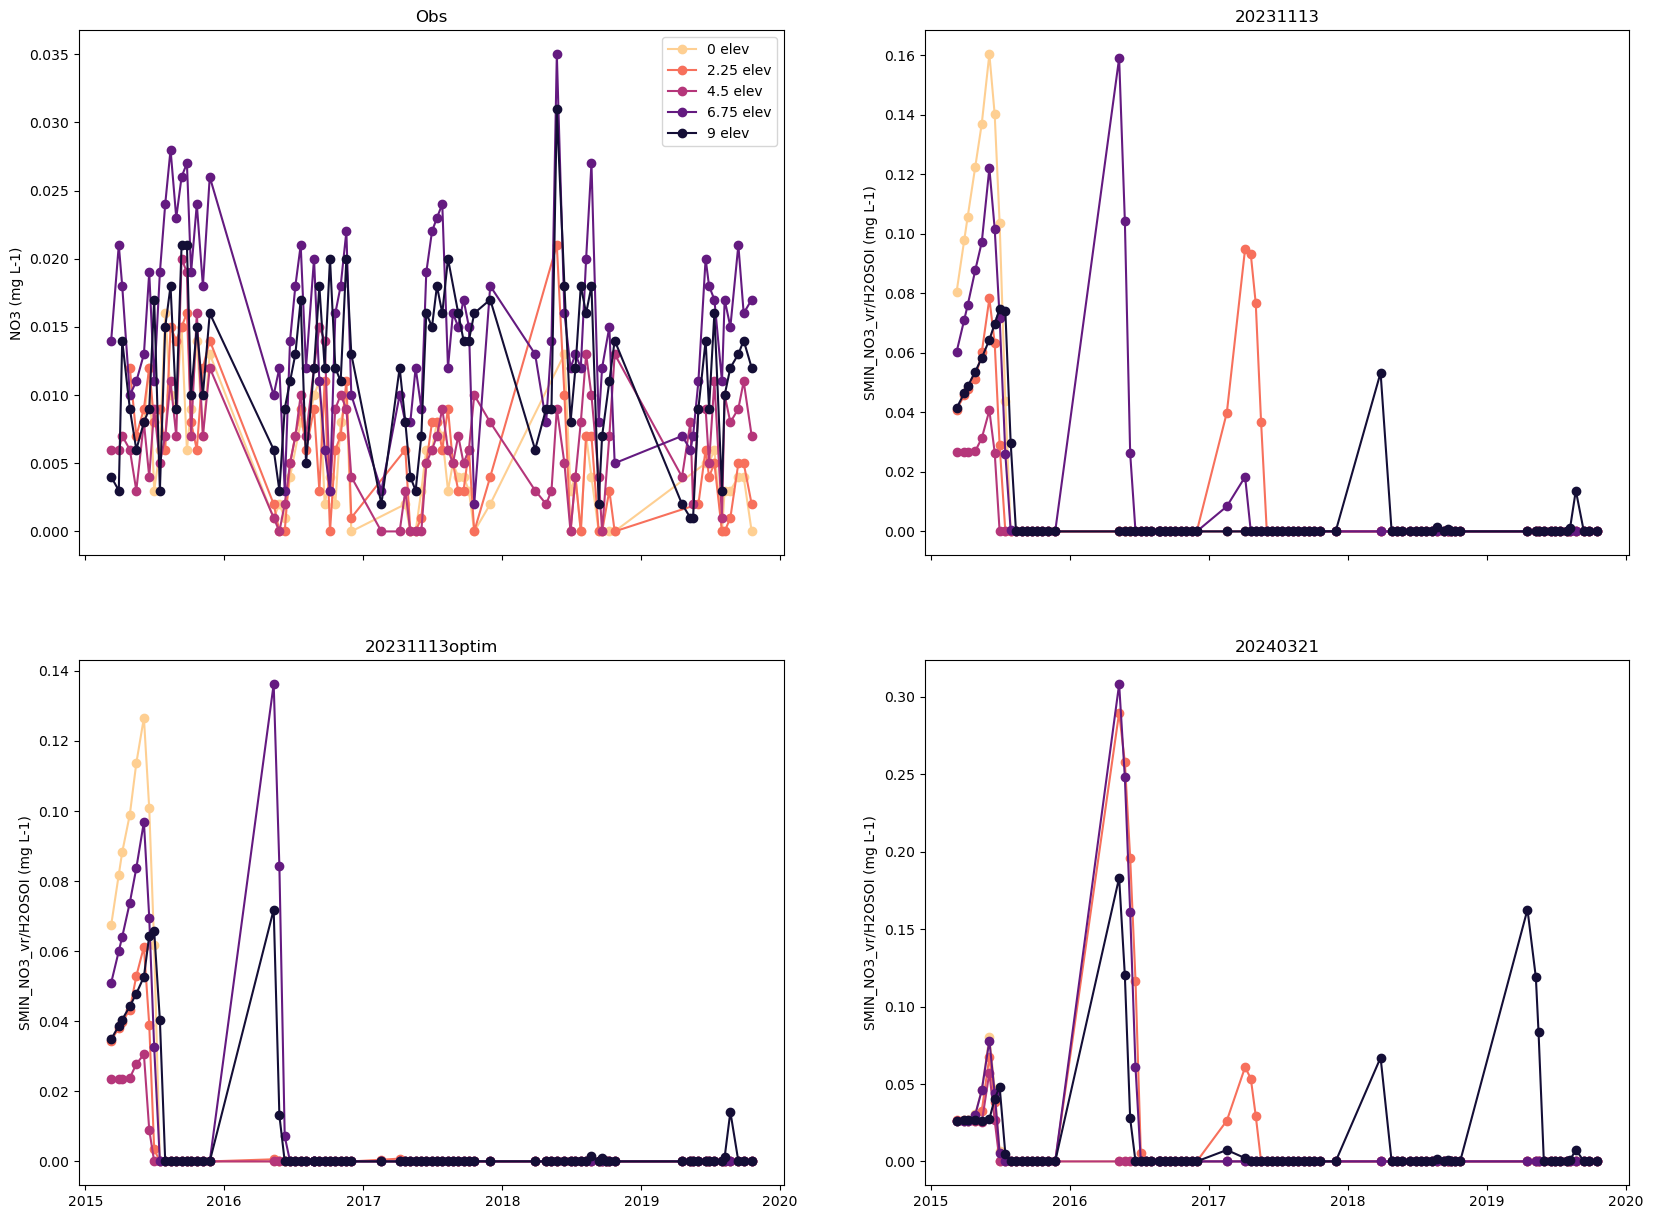

In [7]:
for co2 in ['amb', 'elev']:
    if co2 == 'amb':
        label_list = xticklabels[:5]
    else:
        label_list = xticklabels[5:]

    fig, axes = plt.subplots(2, 2, figsize = (20, 15), sharex = True, sharey = False)

    cmap = get_cmap('magma_r')
    clist = [ cmap((i+0.5) / 5) for i in range(5) ]

    # observation
    ax = axes.flat[0]
    count = 0
    for plot, label in zip(chambers_ordered[co2], label_list):
        ax.plot(data.loc[data['PLOT'] == plot, 'DATE'], 
                data.loc[data['PLOT'] == plot, 'NO3'], 
                '-o', label = label, color = clist[count])
        count += 1
    ax.legend()
    ax.set_title('Obs')
    ax.set_ylabel('NO3 (mg L-1)')

    obs_data_var = data[['PLOT', 'DATE', obs_name]
                        ].set_index(['DATE', 'PLOT']).iloc[:,0].dropna().unstack()

    # simulations
    for p, prefix in enumerate(prefix_list, 1):

        # growing season simulated data
        sims_data_var = sims_data[(prefix, 'SMIN_NO3_vr')]
        sims_data_var = sims_data_var.loc[:, 'hollow']

        sims_data_matched = pd.DataFrame(np.nan, index = obs_data_var.index, 
                                        columns = obs_data_var.columns)
        for plot in chambers_ordered['amb'] + chambers_ordered['elev']:
            sims_data_matched.loc[:, plot] = \
                sims_data_var.loc[obs_data_var.index, plot]

        ax = axes.flat[p]
        count = 0
        for plot, label in zip(chambers_ordered[co2], label_list):
            ax.plot(sims_data_matched.index, 
                    sims_data_matched.loc[:, plot], 
                    '-o', label = label, color = clist[count])
            count += 1
            ax.set_title(prefix)
            ax.set_ylabel('SMIN_NO3_vr/H2OSOI (mg L-1)')

/tmp/ipykernel_2841868/2869672798.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = get_cmap('viridis_r')


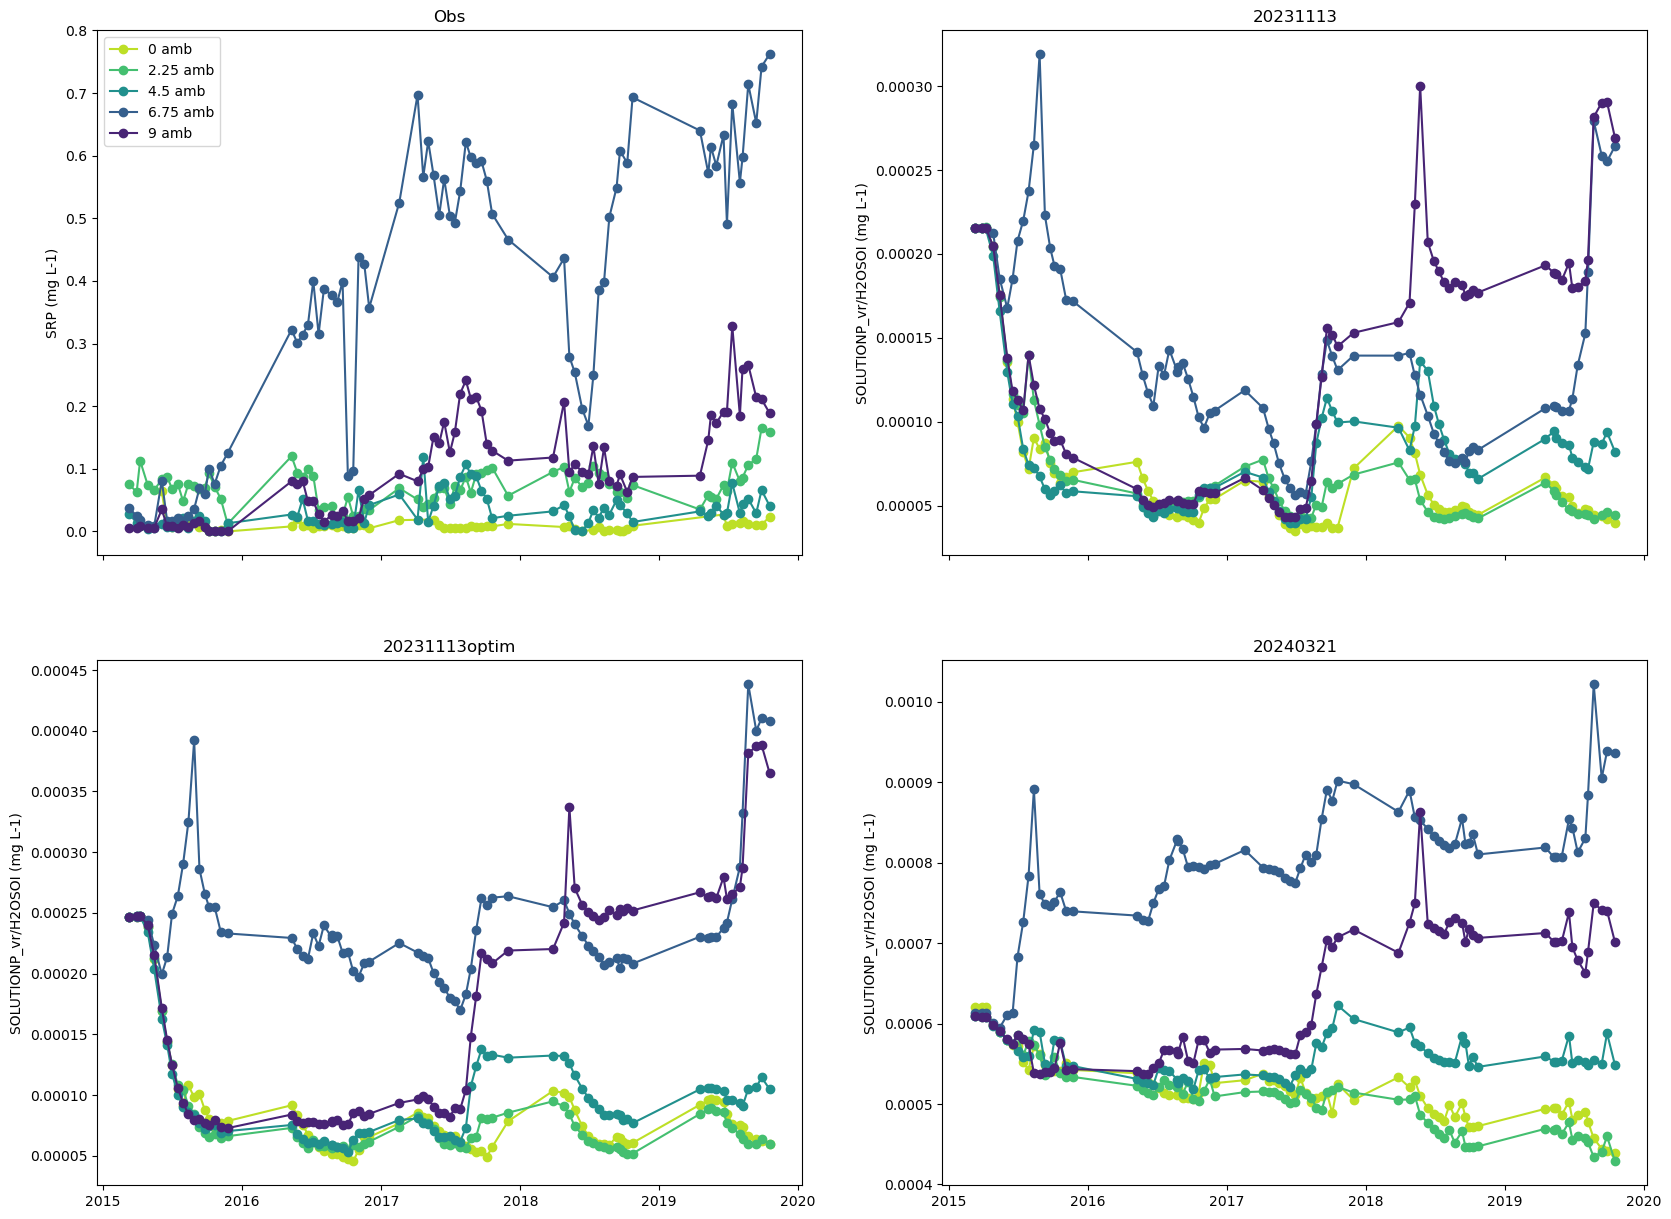

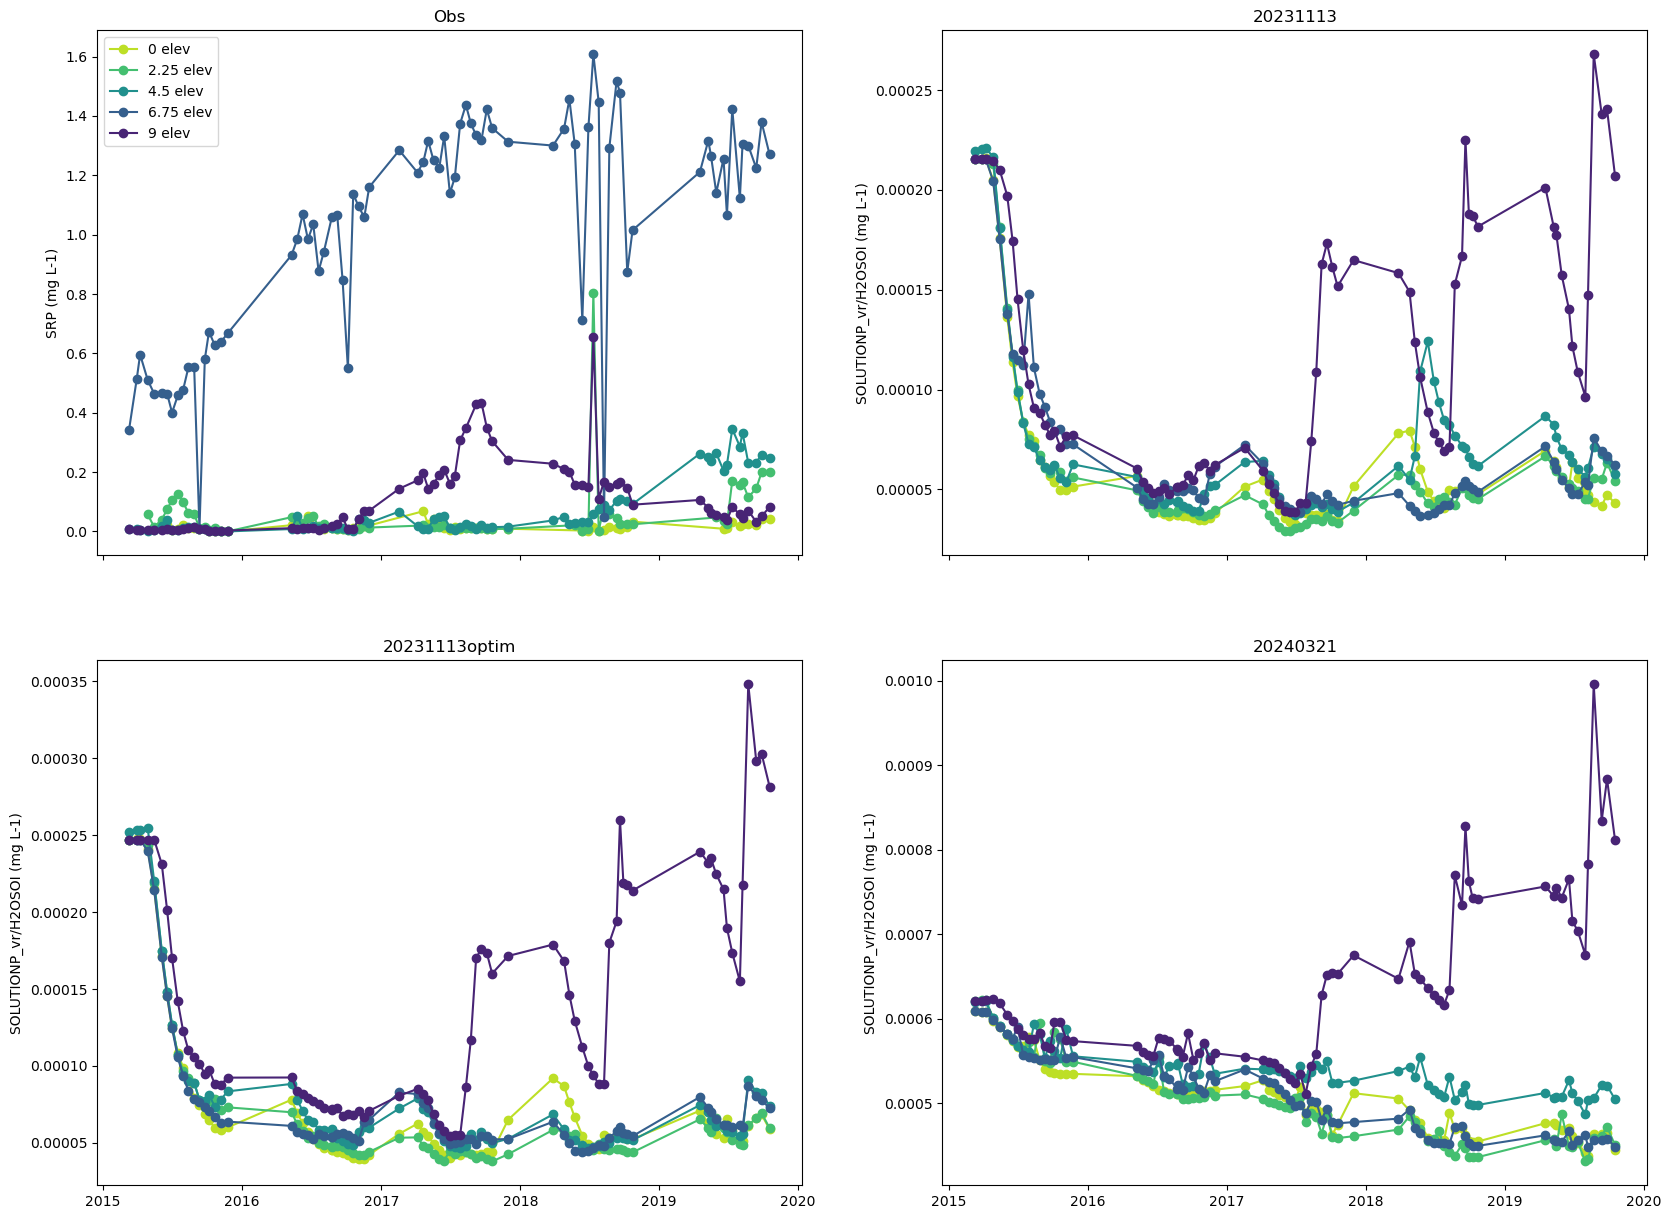

In [8]:
for co2 in ['amb', 'elev']:
    if co2 == 'amb':
        label_list = xticklabels[:5]
    else:
        label_list = xticklabels[5:]

    fig, axes = plt.subplots(2, 2, figsize = (20, 15), sharex = True, sharey = False)

    cmap = get_cmap('viridis_r')
    clist = [ cmap((i+0.5) / 5) for i in range(5) ]

    # observation
    ax = axes.flat[0]
    count = 0
    for plot, label in zip(chambers_ordered[co2], label_list):
        ax.plot(data.loc[data['PLOT'] == plot, 'DATE'], 
                data.loc[data['PLOT'] == plot, 'SRP'], 
                '-o', label = label, color = clist[count])
        count += 1
    ax.legend()
    ax.set_title('Obs')
    ax.set_ylabel('SRP (mg L-1)')

    # simulations
    for p, prefix in enumerate(prefix_list, 1):

        # growing season simulated data
        sims_data_var = sims_data[(prefix, 'SOLUTIONP_vr')]
        sims_data_var = sims_data_var.loc[:, 'hollow']

        sims_data_matched = pd.DataFrame(np.nan, index = obs_data_var.index, 
                                        columns = obs_data_var.columns)
        for plot in chambers_ordered['amb'] + chambers_ordered['elev']:
            sims_data_matched.loc[:, plot] = \
                sims_data_var.loc[obs_data_var.index, plot]

        ax = axes.flat[p]
        count = 0
        for plot, label in zip(chambers_ordered[co2], label_list):
            ax.plot(sims_data_matched.index, 
                    sims_data_matched.loc[:, plot], 
                    '-o', label = label, color = clist[count])
            count += 1
            ax.set_title(prefix)
            ax.set_ylabel('SOLUTIONP_vr/H2OSOI (mg L-1)')